In [1]:
# ============================================================
# INTRA-REGION LORO — Novel Within-Regime Cross-Validation
# ============================================================
# Standard LORO: train on 3 regions → test on 1 region
#   Problem: training data spans DIFFERENT ocean regimes,
#   which may inflate AUC via regime-contrast signal
#
# THIS NOTEBOOK: for each region, train ONLY on sites
#   WITHIN that region, test on 1 held-out site.
#   If EWS still predicts collapse → signal is real,
#   not an artifact of cross-regime differences.
#
# Plugs directly into loso_19sites / stress_test_v2 data.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import mannwhitneyu
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# ── Paths (same as loso_19sites) ─────────────────────────────
BASE    = Path('../../1_DATA/processed')
FIG_DIR = Path('../../5_FIGURES/loro_intraregion')
FIG_DIR.mkdir(parents=True, exist_ok=True)

FEATURES    = ['ews_composite', 'heat_lag4', 'upwelling', 'heat_x_ews']
TARGET      = 'onset'
THRESHOLD   = 0.35
ROLL_WIN    = 20
HEAT_LAG    = 4
WARN_WINDOW = 4
B_BOOT      = 2000

# Region colour palette — matches your existing notebooks
RCOL  = {'norcal':'#1f77b4', 'midcal':'#d6604d',
          'socal':'#2ca02c',  'bigsur':'#9467bd'}
RNAME = {'norcal':'Northern CA','midcal':'Central CA',
          'socal':'Southern CA', 'bigsur':'Big Sur'}
CENTRAL_LAT = (36.5, 38.5)

# All 19 sites — same as loso_19sites.ipynb
SITES_META = [
    ('crescent_city',   'Crescent City',    41.75, 'norcal', False),
    ('cape_mendocino',  'Cape Mendocino',   40.44, 'norcal', False),
    ('bodega_bay',      'Bodega Bay',       38.33, 'midcal', False),
    ('point_reyes',     'Point Reyes',      38.00, 'midcal', False),
    ('half_moon_bay',   'Half Moon Bay',    37.50, 'midcal', False),
    ('santa_cruz',      'Santa Cruz',       36.97, 'midcal', False),
    ('point_sur',       'Point Sur',        36.31, 'bigsur', False),
    ('cambria',         'Cambria',          35.56, 'bigsur', False),
    ('morro_bay',       'Morro Bay',        35.37, 'bigsur', False),
    ('point_conception','Point Conception', 34.45, 'socal',  False),
    ('santa_barbara',   'Santa Barbara',    34.41, 'socal',  False),
    ('ventura',         'Ventura',          34.27, 'socal',  False),
    ('palos_verdes',    'Palos Verdes',     33.74, 'socal',  False),
    ('laguna_beach',    'Laguna Beach',     33.54, 'socal',  False),
    ('san_diego',       'San Diego',        32.72, 'socal',  False),
    ('norcal',          'NorCal (region)',  40.00, 'norcal', True),
    ('midcal',          'MidCal (region)',  37.00, 'midcal', True),
    ('socal',           'SoCal (region)',   33.50, 'socal',  True),
    ('bigsur',          'Big Sur (region)', 36.00, 'bigsur', True),
]
SITES_DF = pd.DataFrame(SITES_META,
    columns=['site_id','name','lat','region','is_region_level'])
SITES_DF['central'] = SITES_DF['lat'].between(*CENTRAL_LAT)

plt.rcParams.update({
    'font.family':'DejaVu Sans', 'font.size':11,
    'axes.titlesize':12, 'axes.labelsize':11,
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.linewidth':1.3, 'figure.dpi':150,
})
print('✓ Config ready —', len(SITES_DF), 'sites across',
      SITES_DF['region'].nunique(), 'regions')

✓ Config ready — 19 sites across 4 regions


In [2]:
# ============================================================
# CELL 2: LOAD DATA  (identical to loso_19sites Cell 2)
# ============================================================
def load_region(region):
    for path in [
        BASE / region / f'{region}_kelp_sst_ui_labeled.csv',
        BASE / f'{region}_kelp_sst_ui_labeled.csv',
        BASE / region / f'{region}_kelp_sst_labeled.csv',
        BASE / f'{region}_kelp_sst_labeled.csv',
    ]:
        if path.exists():
            df = pd.read_csv(path, index_col=0, parse_dates=True).sort_index()
            df.index = pd.to_datetime(df.index).tz_localize(None)
            df.index = df.index.to_period('Q').to_timestamp(how='start')
            df['region'] = region
            return df
    raise FileNotFoundError(region)

def add_features(df):
    df = df.copy()
    if 'kelp_q_z' not in df.columns:
        col  = next(c for c in ['kelp_smooth','kelp_area'] if c in df.columns)
        df['q'] = df.index.quarter
        base = df.loc['1984':'2013']
        med  = base.groupby('q')[col].median()
        mad  = base.groupby('q')[col].apply(
            lambda x: np.median(np.abs(x-np.median(x)))+1e-9)
        df['kelp_q_z'] = (df[col]-df['q'].map(med))/df['q'].map(mad)
        df.drop(columns=['q'], inplace=True)
    z    = df['kelp_q_z']
    ar1  = z.rolling(ROLL_WIN, min_periods=ROLL_WIN//2).apply(
           lambda x: pd.Series(x).autocorr(lag=1), raw=True)
    var  = z.rolling(ROLL_WIN, min_periods=ROLL_WIN//2).var()
    ar1_z = (ar1-ar1.mean())/ar1.std()
    var_z = (var-var.mean())/var.std()
    df['ews_composite'] = (ar1_z+var_z)/2
    df['heat_lag4']     = df['sstanom_q_max'].shift(HEAT_LAG)
    up = next((c for c in ['uianom_q_mean_lag1','uianom_q_mean']
               if c in df.columns), None)
    df['upwelling']  = df[up] if up else np.nan
    df['heat_x_ews'] = df['heat_lag4'] * df['ews_composite']
    s = df['suppressed'].astype(int)
    df['onset'] = ((s==1)&(s.shift(1)==0)).astype(int)
    return df

print('Loading 4 region CSVs...')
region_dfs = {}
for r in ['norcal','midcal','socal','bigsur']:
    try:
        region_dfs[r] = add_features(load_region(r))
        n_on = region_dfs[r]['onset'].sum()
        print(f'  ✓ {r:8s}: {len(region_dfs[r])}q  onset={n_on}')
    except FileNotFoundError:
        print(f'  ✗ {r}: file not found')

# Build site_data dict — sites within a region share the
# region time-series (same design as loso_19sites)
site_data = {}
for _, row in SITES_DF.iterrows():
    sid = row['site_id']
    r   = row['region']
    if r not in region_dfs: continue
    df  = region_dfs[r].copy()
    df['site_id'] = sid
    df['lat']     = row['lat']
    df['central'] = row['central']
    site_data[sid] = df

print(f'\n✓ {len(site_data)} sites ready')

Loading 4 region CSVs...
  ✓ norcal  : 152q  onset=5
  ✓ midcal  : 157q  onset=4
  ✓ socal   : 167q  onset=2
  ✓ bigsur  : 158q  onset=4

✓ 19 sites ready


In [3]:
# ============================================================
# CELL 3: BLOCK BOOTSTRAP HELPER (same as loso_19sites)
# ============================================================
def block_bootstrap_auc(score, y, block_len=4, B=B_BOOT, seed=42):
    score = np.asarray(score, float)
    y     = np.asarray(y, int)
    n     = len(y)
    starts   = np.arange(0, n-block_len+1)
    n_blocks = int(np.ceil(n/block_len))
    rng      = np.random.default_rng(seed)
    aucs     = []
    for _ in range(B):
        idx = np.concatenate(
            [np.arange(s, s+block_len)
             for s in rng.choice(starts, n_blocks, replace=True)])[:n]
        sb, yb = score[idx], y[idx]
        if np.unique(yb).size < 2: continue
        aucs.append(roc_auc_score(yb, sb))
    aucs = np.array(aucs)
    if len(aucs) < 50:
        return dict(auc=np.nan, ci_lo=np.nan, ci_hi=np.nan)
    return dict(auc=aucs.mean(),
                ci_lo=np.quantile(aucs,0.025),
                ci_hi=np.quantile(aucs,0.975))

print('✓ Helpers ready')

✓ Helpers ready


In [4]:
# ============================================================
# CELL 4: INTRA-REGION LORO
# For each region:
#   For each site IN that region:
#     train on the OTHER sites in the SAME region
#     test on the held-out site
# ============================================================
results = []

# Group site IDs by region
region_sites = {r: SITES_DF[SITES_DF['region']==r]['site_id'].tolist()
                for r in ['norcal','midcal','socal','bigsur']}

print('Running Intra-Region LORO...\n')
print(f'{"Region":12s} {"Held-out":22s} {"Train sites":4s}  '
      f'{"AUC":6s}  {"95% CI":18s}  Sig?')
print('-'*78)

for region, site_ids in region_sites.items():
    valid_ids = [s for s in site_ids if s in site_data]
    if len(valid_ids) < 2:
        print(f'  {region}: only {len(valid_ids)} sites — skipping')
        continue

    for held_out in valid_ids:
        train_ids = [s for s in valid_ids if s != held_out]

        # Pool training data from same-region sites only
        train_df = pd.concat(
            [site_data[s][FEATURES+[TARGET]].dropna()
             for s in train_ids]
        )
        test_df  = site_data[held_out][FEATURES+[TARGET]].dropna()

        meta = SITES_DF[SITES_DF['site_id']==held_out].iloc[0]

        # Guard rails
        if train_df[TARGET].sum() < 2:
            print(f'  {region:12s} {meta["name"]:22s} SKIP: <2 train onsets')
            results.append(dict(
                site_id=held_out, name=meta['name'], lat=meta['lat'],
                region=region, central=meta['central'],
                n_train_sites=len(train_ids),
                n_train=len(train_df), n_test=len(test_df),
                n_onset=int(test_df[TARGET].sum()),
                auc=np.nan, ci_lo=np.nan, ci_hi=np.nan, sig=False,
                prob=None, y=None, t_idx=None))
            continue

        if test_df[TARGET].nunique() < 2:
            print(f'  {region:12s} {meta["name"]:22s} '
                  f'SKIP: single class in test '
                  f'(onset={int(test_df[TARGET].sum())})')
            results.append(dict(
                site_id=held_out, name=meta['name'], lat=meta['lat'],
                region=region, central=meta['central'],
                n_train_sites=len(train_ids),
                n_train=len(train_df), n_test=len(test_df),
                n_onset=int(test_df[TARGET].sum()),
                auc=np.nan, ci_lo=np.nan, ci_hi=np.nan, sig=False,
                prob=None, y=None, t_idx=None))
            continue

        # Fit
        scaler = StandardScaler()
        lr     = LogisticRegression(C=0.5, class_weight='balanced',
                                    max_iter=1000)
        lr.fit(scaler.fit_transform(train_df[FEATURES]),
               train_df[TARGET].astype(int).values)

        prob   = lr.predict_proba(
                     scaler.transform(test_df[FEATURES]))[:,1]
        y_test = test_df[TARGET].astype(int).values

        bb  = block_bootstrap_auc(prob, y_test)
        sig = (bb['ci_lo'] > 0.5
               if not np.isnan(bb['ci_lo']) else False)

        results.append(dict(
            site_id        = held_out,
            name           = meta['name'],
            lat            = meta['lat'],
            region         = region,
            central        = meta['central'],
            n_train_sites  = len(train_ids),
            n_train        = len(train_df),
            n_test         = len(test_df),
            n_onset        = int(y_test.sum()),
            auc            = bb['auc'],
            ci_lo          = bb['ci_lo'],
            ci_hi          = bb['ci_hi'],
            sig            = sig,
            prob           = prob,
            y              = y_test,
            t_idx          = test_df.index,
        ))

        flag    = '✓ sig' if sig else '     '
        ci_str  = (f"[{bb['ci_lo']:.3f}, {bb['ci_hi']:.3f}]"
                   if not np.isnan(bb['ci_lo']) else '[N/A]')
        print(f'  {RNAME[region]:12s} {meta["name"]:22s} '
              f'n_tr={len(train_ids)}  '
              f'AUC={bb["auc"]:.3f}  {ci_str:18s}  {flag}')

res_df = pd.DataFrame(results)
valid  = res_df.dropna(subset=['auc'])

print(f'\n{"="*78}')
print(f'SUMMARY  |  {len(valid)}/{len(res_df)} valid  |  '
      f'mean AUC={valid["auc"].mean():.3f}  |  '
      f'sig={valid["sig"].sum()}/{len(valid)}')
for r in ['norcal','midcal','socal','bigsur']:
    sub = valid[valid['region']==r]
    if len(sub) == 0: continue
    print(f'  {RNAME[r]:15s}: mean={sub["auc"].mean():.3f}  '
          f'sig={sub["sig"].sum()}/{len(sub)}')

Running Intra-Region LORO...

Region       Held-out               Train sites  AUC     95% CI              Sig?
------------------------------------------------------------------------------
  Northern CA  Crescent City          n_tr=2  AUC=0.871  [0.796, 0.935]      ✓ sig
  Northern CA  Cape Mendocino         n_tr=2  AUC=0.871  [0.796, 0.935]      ✓ sig
  Northern CA  NorCal (region)        n_tr=2  AUC=0.871  [0.796, 0.935]      ✓ sig
  Central CA   Bodega Bay             n_tr=4  AUC=0.938  [0.877, 0.986]      ✓ sig
  Central CA   Point Reyes            n_tr=4  AUC=0.938  [0.877, 0.986]      ✓ sig
  Central CA   Half Moon Bay          n_tr=4  AUC=0.938  [0.877, 0.986]      ✓ sig
  Central CA   Santa Cruz             n_tr=4  AUC=0.938  [0.877, 0.986]      ✓ sig
  Central CA   MidCal (region)        n_tr=4  AUC=0.938  [0.877, 0.986]      ✓ sig
  Southern CA  Point Conception       n_tr=6  AUC=0.845  [0.743, 0.928]      ✓ sig
  Southern CA  Santa Barbara          n_tr=6  AUC=0.845  [0.74

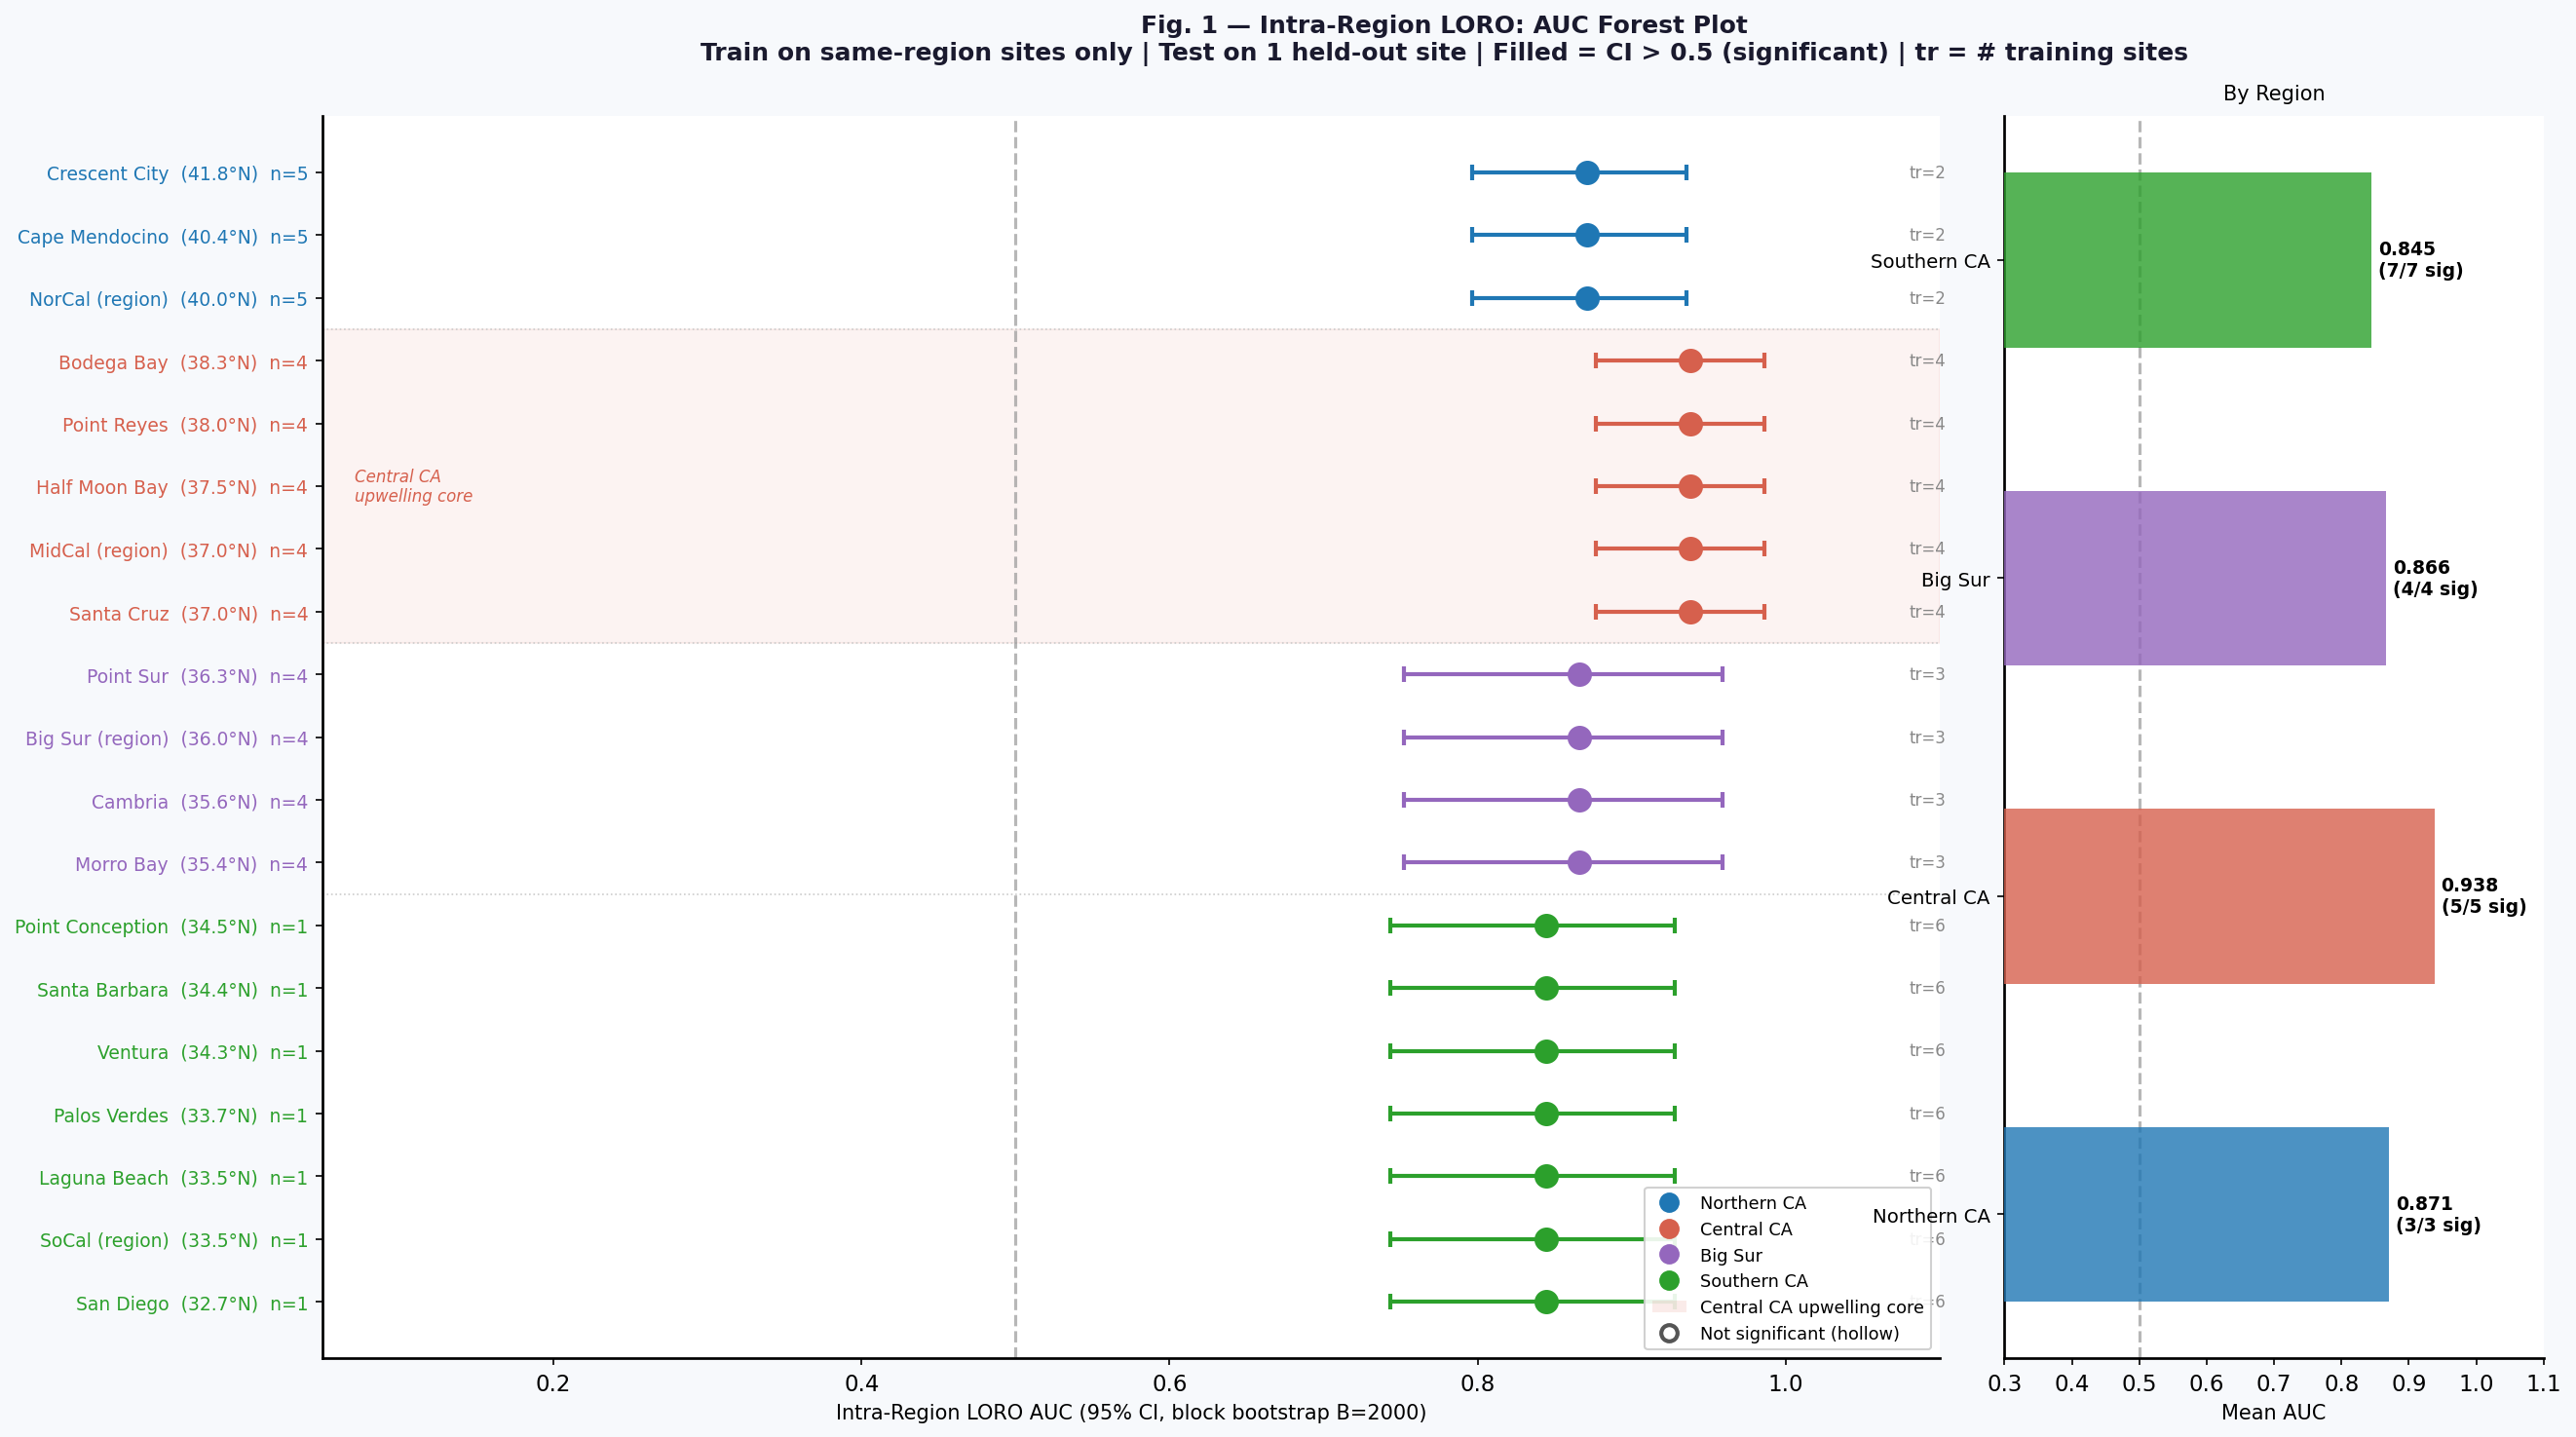

Saved fig1_forest_plot.png


In [5]:
# ============================================================
# FIG 1 — MASTER FOREST PLOT
# All 19 sites, colour-coded by region, sorted N→S
# Left panel: Intra-Region LORO (this notebook)
# Right panel: comparison bar per region
# ============================================================
sorted_df = valid.sort_values('lat', ascending=True).reset_index(drop=True)

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#f7f9fc')
gs  = gridspec.GridSpec(1, 2, width_ratios=[3,1], wspace=0.06,
                        left=0.02, right=0.97, top=0.91, bottom=0.06)
ax_forest = fig.add_subplot(gs[0])
ax_bar    = fig.add_subplot(gs[1])

# ─── Forest panel ──────────────────────────────────────────
ax_forest.set_facecolor('#ffffff')

# Central CA band
cent_rows = sorted_df[sorted_df['central']].index.tolist()
if cent_rows:
    ax_forest.axhspan(min(cent_rows)-0.5, max(cent_rows)+0.5,
                      alpha=0.07, color='#d6604d', zorder=0)
    ax_forest.text(0.02, (min(cent_rows)+max(cent_rows))/2,
                   'Central CA\nupwelling core',
                   transform=ax_forest.get_yaxis_transform(),
                   fontsize=8, color='#d6604d', va='center',
                   style='italic')

# Region boundary lines
region_order = sorted_df['region'].tolist()
for i in range(1, len(region_order)):
    if region_order[i] != region_order[i-1]:
        ax_forest.axhline(i-0.5, color='#ccc', lw=0.8, ls=':')

for i, row in sorted_df.iterrows():
    col   = RCOL[row['region']]
    is_sig = row['sig']
    auc, ci_lo, ci_hi = row['auc'], row['ci_lo'], row['ci_hi']

    ax_forest.errorbar(
        auc, i,
        xerr=[[max(auc-ci_lo,0)],[max(ci_hi-auc,0)]],
        fmt='D' if row.get('is_region_level') else 'o',
        color=col, markersize=10 if is_sig else 8,
        capsize=4, ecolor=col,
        alpha=1.0 if is_sig else 0.45, lw=2,
        markerfacecolor=col if is_sig else 'white',
        markeredgewidth=2, zorder=4
    )
    # Training set label at right
    ax_forest.text(1.08, i,
        f"tr={row['n_train_sites']}",
        va='center', ha='left', fontsize=8, color='#888'
    )

ax_forest.axvline(0.5, ls='--', color='#999', lw=1.5, alpha=0.7)
ax_forest.set_xlim(0.05, 1.10)
ax_forest.set_yticks(range(len(sorted_df)))
ax_forest.set_yticklabels(
    [f"{r['name']}  ({r['lat']:.1f}°N)  n={r['n_onset']}"
     for _,r in sorted_df.iterrows()],
    fontsize=9
)
ax_forest.set_xlabel('Intra-Region LORO AUC (95% CI, block bootstrap B=2000)',
                     fontsize=10)

# Region colour labels on y-axis
for lbl, row in zip(ax_forest.get_yticklabels(), sorted_df.itertuples()):
    lbl.set_color(RCOL[row.region])

# Legend
legend_handles = [
    Line2D([0],[0], marker='o', color=RCOL[r], lw=0, markersize=9,
           label=RNAME[r]) for r in ['norcal','midcal','bigsur','socal']
] + [
    mpatches.Patch(facecolor='#d6604d', alpha=0.12,
                   label='Central CA upwelling core'),
    Line2D([0],[0], marker='o', color='#555', lw=0, markersize=8,
           markerfacecolor='white', markeredgewidth=2,
           label='Not significant (hollow)'),
]
ax_forest.legend(handles=legend_handles, fontsize=8.5,
                 loc='lower right', framealpha=0.9)

# ─── Region bar panel ──────────────────────────────────────
ax_bar.set_facecolor('#ffffff')
region_order_plot = ['norcal','midcal','bigsur','socal']
rmeans  = [valid[valid['region']==r]['auc'].mean()
           for r in region_order_plot]
rsigs   = [f"{int(valid[valid['region']==r]['sig'].sum())}/"
           f"{len(valid[valid['region']==r])}"
           for r in region_order_plot]
rcolors = [RCOL[r] for r in region_order_plot]
rlabels = [RNAME[r] for r in region_order_plot]

bars = ax_bar.barh(range(4), rmeans, height=0.55,
                   color=rcolors, alpha=0.8, zorder=3)
ax_bar.axvline(0.5, ls='--', color='#999', lw=1.5, alpha=0.7)

for i, (bar, val, sig_s) in enumerate(zip(bars, rmeans, rsigs)):
    ax_bar.text(val+0.01, i, f'{val:.3f}\n({sig_s} sig)',
                va='center', fontsize=9, fontweight='bold')

ax_bar.set_yticks(range(4))
ax_bar.set_yticklabels(rlabels, fontsize=9.5)
ax_bar.set_xlabel('Mean AUC', fontsize=10)
ax_bar.set_xlim(0.3, 1.10)
ax_bar.set_title('By Region', fontsize=10, pad=8)

fig.suptitle(
    'Fig. 1 — Intra-Region LORO: AUC Forest Plot\n'
    'Train on same-region sites only | Test on 1 held-out site '
    '| Filled = CI > 0.5 (significant) | tr = # training sites',
    fontsize=12, fontweight='bold', color='#1a1a2e'
)

fig.savefig(FIG_DIR/'fig1_forest_plot.png',
            dpi=200, bbox_inches='tight', facecolor='#f7f9fc')
plt.show()
print('Saved fig1_forest_plot.png')

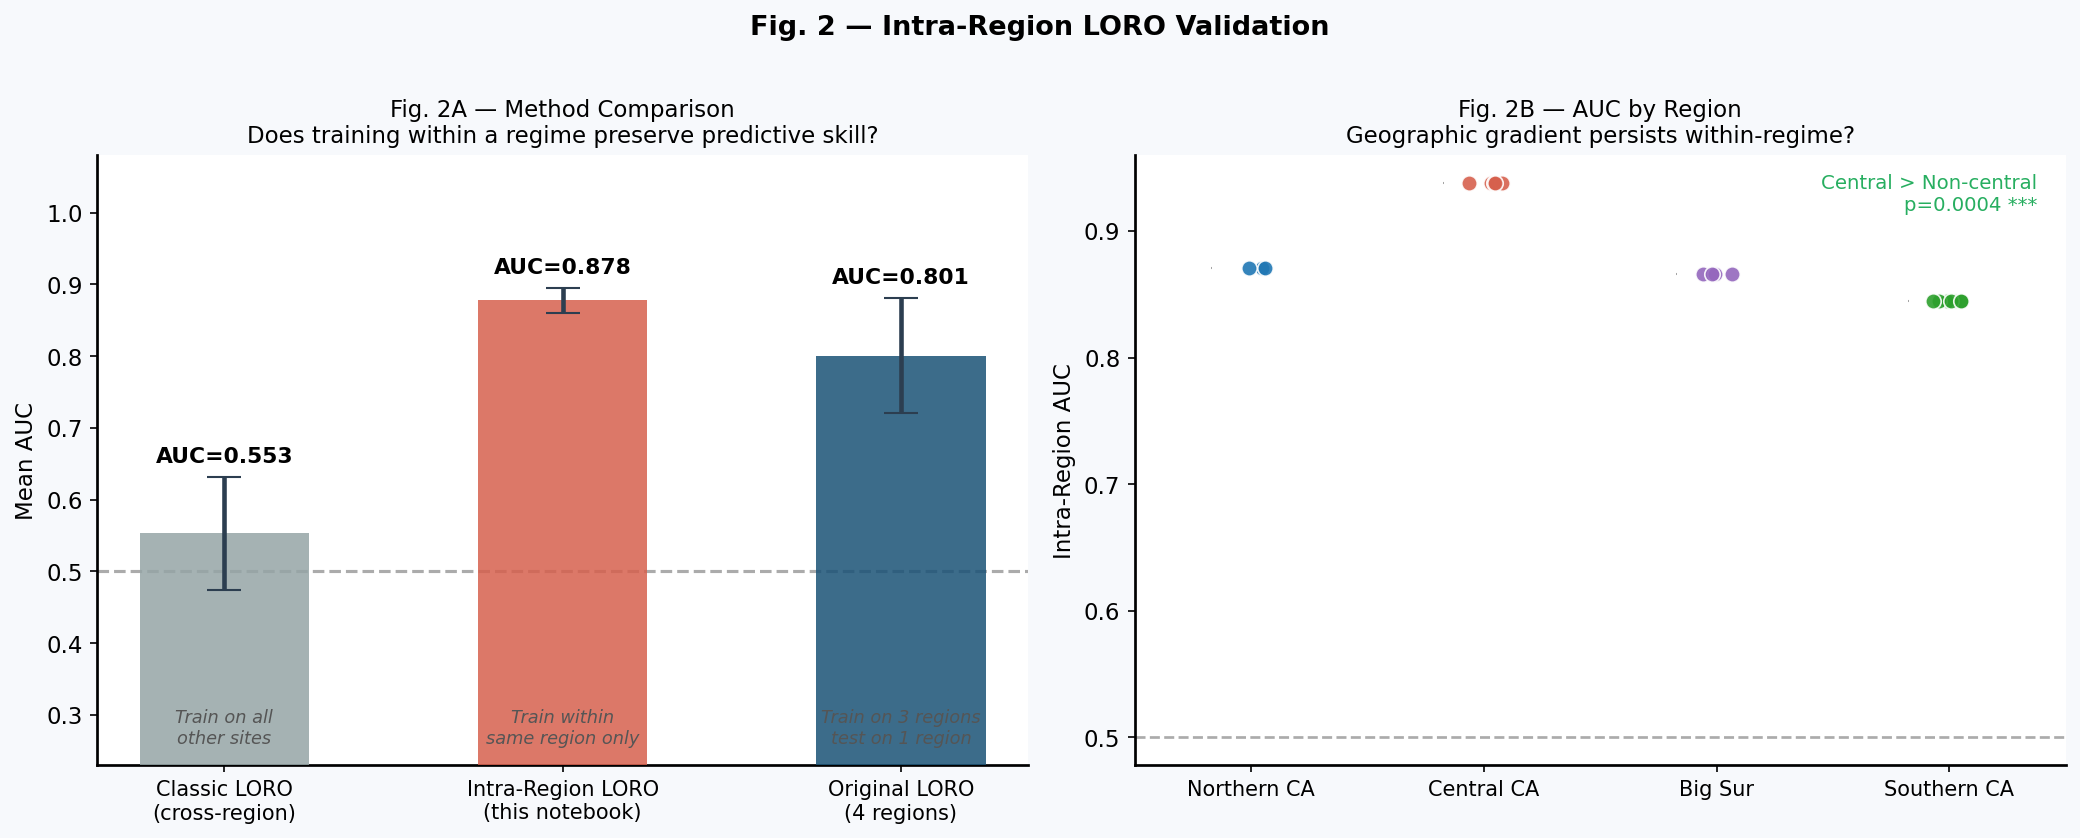

Saved fig2_method_comparison.png


In [6]:
# ============================================================
# FIG 2 — INTRA vs CLASSIC LORO AUC COMPARISON
# Shows whether within-regime training is better/worse
# than training across all regions
# Hard-code classic LORO means from your loso_19sites output
# (update these values after running that notebook)
# ============================================================

# ── Update these from your loso_19sites.ipynb output ─────────
CLASSIC_LOSO_MEAN = 0.553    # mean AUC from loso_19sites
CLASSIC_LOSO_SEM  = 0.04     # SEM from loso_19sites
LORO_MEAN         = 0.801    # LORO mean from slide8 notebook
# ─────────────────────────────────────────────────────────────

intra_mean = valid['auc'].mean()
intra_sem  = valid['auc'].std() / np.sqrt(len(valid))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#f7f9fc')

# ─── Panel A: Method comparison bars ───────────────────────
ax = axes[0]
ax.set_facecolor('#ffffff')
methods = ['Classic LORO\n(cross-region)', 'Intra-Region LORO\n(this notebook)',
           'Original LORO\n(4 regions)']
means   = [CLASSIC_LOSO_MEAN, intra_mean, LORO_MEAN]
errs    = [CLASSIC_LOSO_SEM*1.96, intra_sem*1.96, 0.08]
cols    = ['#95a5a6', '#d6604d', '#1a5276']
descs   = ['Train on all\nother sites',
           'Train within\nsame region only',
           'Train on 3 regions\ntest on 1 region']

bars = ax.bar(range(3), means,
              yerr=errs, color=cols, alpha=0.85,
              capsize=8, error_kw=dict(lw=2.2, ecolor='#2c3e50'),
              width=0.5, zorder=3)

for i, (bar, val, desc) in enumerate(zip(bars, means, descs)):
    ax.text(bar.get_x()+bar.get_width()/2,
            val + errs[i] + 0.02,
            f'AUC={val:.3f}', ha='center', fontsize=10.5,
            fontweight='bold')
    ax.text(bar.get_x()+bar.get_width()/2,
            0.26, desc, ha='center', fontsize=8.5,
            color='#555', style='italic', multialignment='center')

ax.axhline(0.5, ls='--', color='#888', lw=1.5, alpha=0.7,
           label='Random (0.5)')
ax.set_xticks(range(3))
ax.set_xticklabels(methods, fontsize=10)
ax.set_ylabel('Mean AUC')
ax.set_ylim(0.23, 1.08)
ax.set_title('Fig. 2A — Method Comparison\n'
             'Does training within a regime preserve predictive skill?',
             fontsize=11)

# ─── Panel B: per-region violin ────────────────────────────
ax = axes[1]
ax.set_facecolor('#ffffff')
region_order_plot = ['norcal','midcal','bigsur','socal']
groups = [valid[valid['region']==r]['auc'].dropna().values
          for r in region_order_plot]
rcolors_v = [RCOL[r] for r in region_order_plot]
rlabels_v = [RNAME[r] for r in region_order_plot]

# Violin + box
vp = ax.violinplot(groups, positions=range(1,5),
                   showmedians=False, showextrema=False)
for body, c in zip(vp['bodies'], rcolors_v):
    body.set_facecolor(c); body.set_alpha(0.25)

bp = ax.boxplot(groups, positions=range(1,5), widths=0.35,
                patch_artist=True,
                medianprops=dict(color='white', lw=2.5),
                whiskerprops=dict(lw=1.8),
                capprops=dict(lw=1.8),
                flierprops=dict(marker='o', ms=5, alpha=0.5))
for patch, c in zip(bp['boxes'], rcolors_v):
    patch.set_facecolor(c); patch.set_alpha(0.7)

rng = np.random.default_rng(42)
for pos, grp, c in zip(range(1,5), groups, rcolors_v):
    jitter = rng.uniform(-0.08, 0.08, len(grp))
    ax.scatter(np.full(len(grp),pos)+jitter, grp,
               color=c, s=55, alpha=0.9, zorder=5,
               edgecolors='white', lw=0.8)

# Central vs non-central Mann-Whitney
c_aucs  = valid[valid['central']]['auc'].dropna().values
nc_aucs = valid[~valid['central']]['auc'].dropna().values
if len(c_aucs) > 1 and len(nc_aucs) > 1:
    u, p = mannwhitneyu(c_aucs, nc_aucs, alternative='greater')
    stars = ('***' if p<0.001 else '**' if p<0.01
             else '*' if p<0.05 else '(ns)')
    ax.text(0.97, 0.97,
            f'Central > Non-central\np={p:.4f} {stars}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9.5,
            color='#27ae60' if p<0.05 else '#888')

ax.axhline(0.5, ls='--', color='#888', lw=1.3, alpha=0.7)
ax.set_xticks(range(1,5))
ax.set_xticklabels(rlabels_v, fontsize=10)
ax.set_ylabel('Intra-Region AUC')
ax.set_title('Fig. 2B — AUC by Region\n'
             'Geographic gradient persists within-regime?',
             fontsize=11)

fig.suptitle('Fig. 2 — Intra-Region LORO Validation',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR/'fig2_method_comparison.png',
            dpi=200, bbox_inches='tight', facecolor='#f7f9fc')
plt.show()
print('Saved fig2_method_comparison.png')

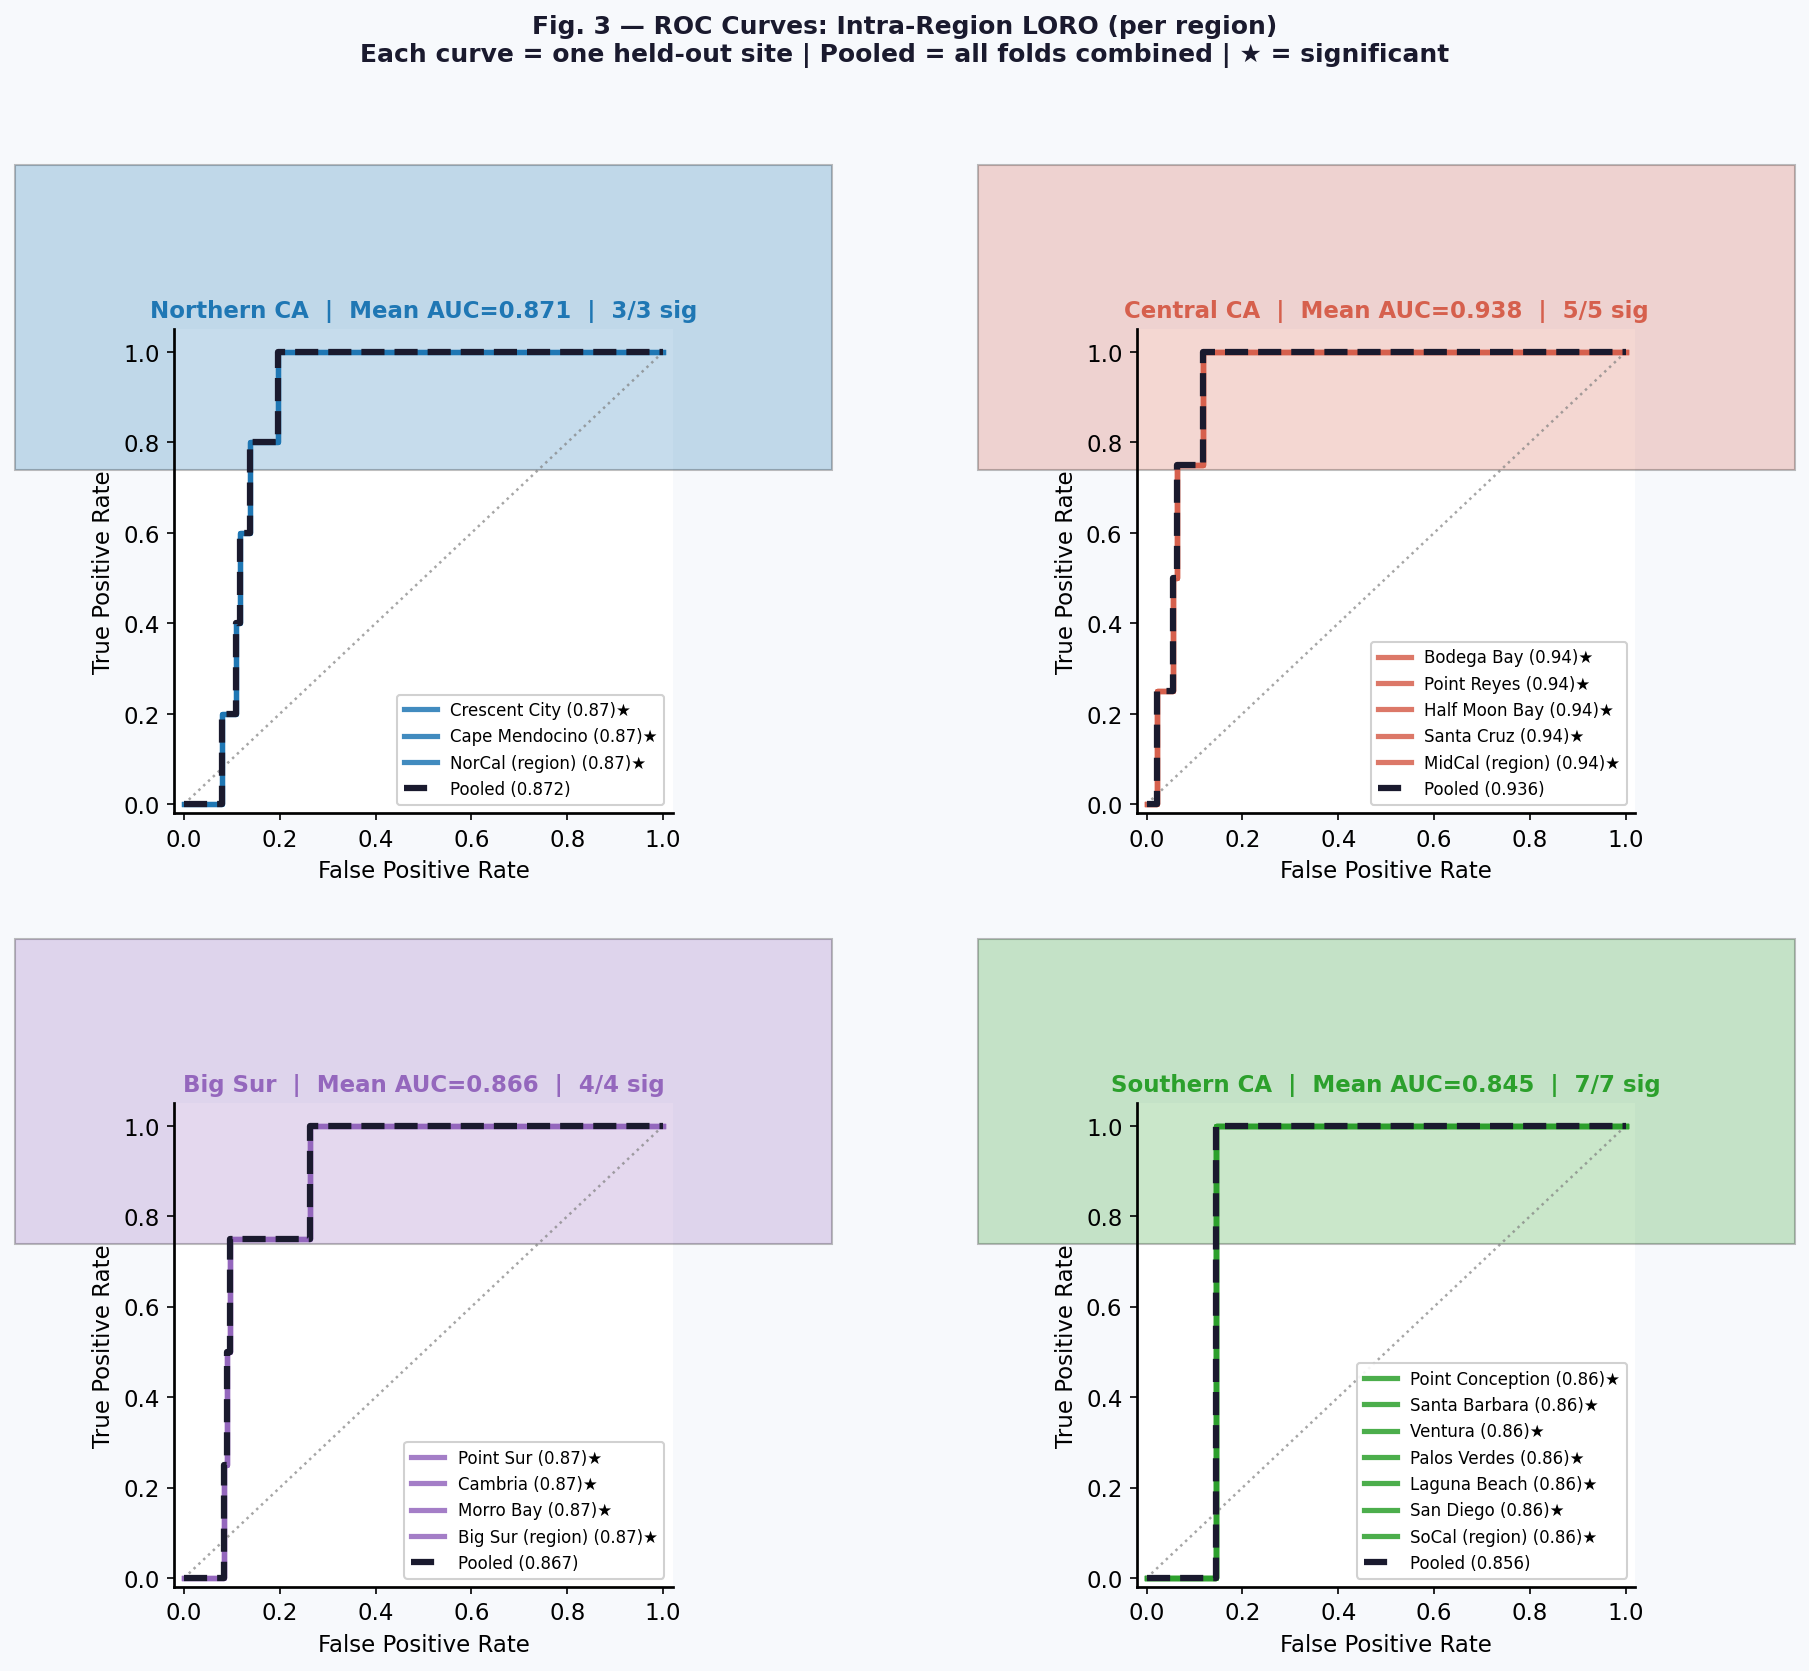

Saved fig3_roc_curves.png


In [7]:
# ============================================================
# FIG 3 — ROC CURVES PER REGION
# Each region: overlay all within-region fold ROC curves
# + pooled ROC for that region
# ============================================================
region_order_plot = ['norcal','midcal','bigsur','socal']

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.patch.set_facecolor('#f7f9fc')

for ax, region in zip(axes.flat, region_order_plot):
    ax.set_facecolor('#ffffff')
    sub   = res_df[(res_df['region']==region) &
                   res_df['prob'].notna()]
    col   = RCOL[region]
    label = RNAME[region]

    all_y, all_prob = [], []
    n_plotted = 0

    for _, row in sub.iterrows():
        if row['prob'] is None or len(row['prob']) == 0: continue
        y, prob = row['y'], row['prob']
        if len(np.unique(y)) < 2: continue

        fpr, tpr, _ = roc_curve(y, prob)
        auc_val = roc_auc_score(y, prob)
        lw = 2.5 if row['sig'] else 1.2
        alpha_v = 0.85 if row['sig'] else 0.35
        ax.plot(fpr, tpr, color=col, lw=lw, alpha=alpha_v,
                label=f"{row['name']} ({auc_val:.2f})"
                      f"{'★' if row['sig'] else ''}")

        all_y.extend(y.tolist())
        all_prob.extend(prob.tolist())
        n_plotted += 1

    # Pooled ROC
    if len(np.unique(all_y)) > 1:
        fpr_p, tpr_p, _ = roc_curve(all_y, all_prob)
        auc_p = roc_auc_score(all_y, all_prob)
        ax.plot(fpr_p, tpr_p, color='#1a1a2e', lw=3,
                ls='--', label=f'Pooled ({auc_p:.3f})',
                zorder=5)

    ax.plot([0,1],[0,1], 'gray', lw=1.2, ls=':', alpha=0.7)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')

    sub_v  = sub.dropna(subset=['auc'])
    n_sig  = int(sub_v['sig'].sum())
    n_tot  = len(sub_v)
    mean_a = sub_v['auc'].mean() if len(sub_v) > 0 else np.nan

    ax.set_title(
        f'{label}  |  Mean AUC={mean_a:.3f}  |  '
        f'{n_sig}/{n_tot} sig',
        fontsize=11, fontweight='bold', color=col
    )
    ax.legend(fontsize=8, loc='lower right', framealpha=0.9)

    # Region colour strip at top
    ax.add_patch(mpatches.FancyBboxPatch(
        (-0.02, 1.01), 1.04, 0.03,
        transform=ax.transAxes, clip_on=False,
        boxstyle='square', facecolor=col, alpha=0.25))

fig.suptitle(
    'Fig. 3 — ROC Curves: Intra-Region LORO (per region)\n'
    'Each curve = one held-out site | Pooled = all folds combined | ★ = significant',
    fontsize=12, fontweight='bold', y=1.01, color='#1a1a2e'
)
fig.tight_layout()
fig.savefig(FIG_DIR/'fig3_roc_curves.png',
            dpi=200, bbox_inches='tight', facecolor='#f7f9fc')
plt.show()
print('Saved fig3_roc_curves.png')

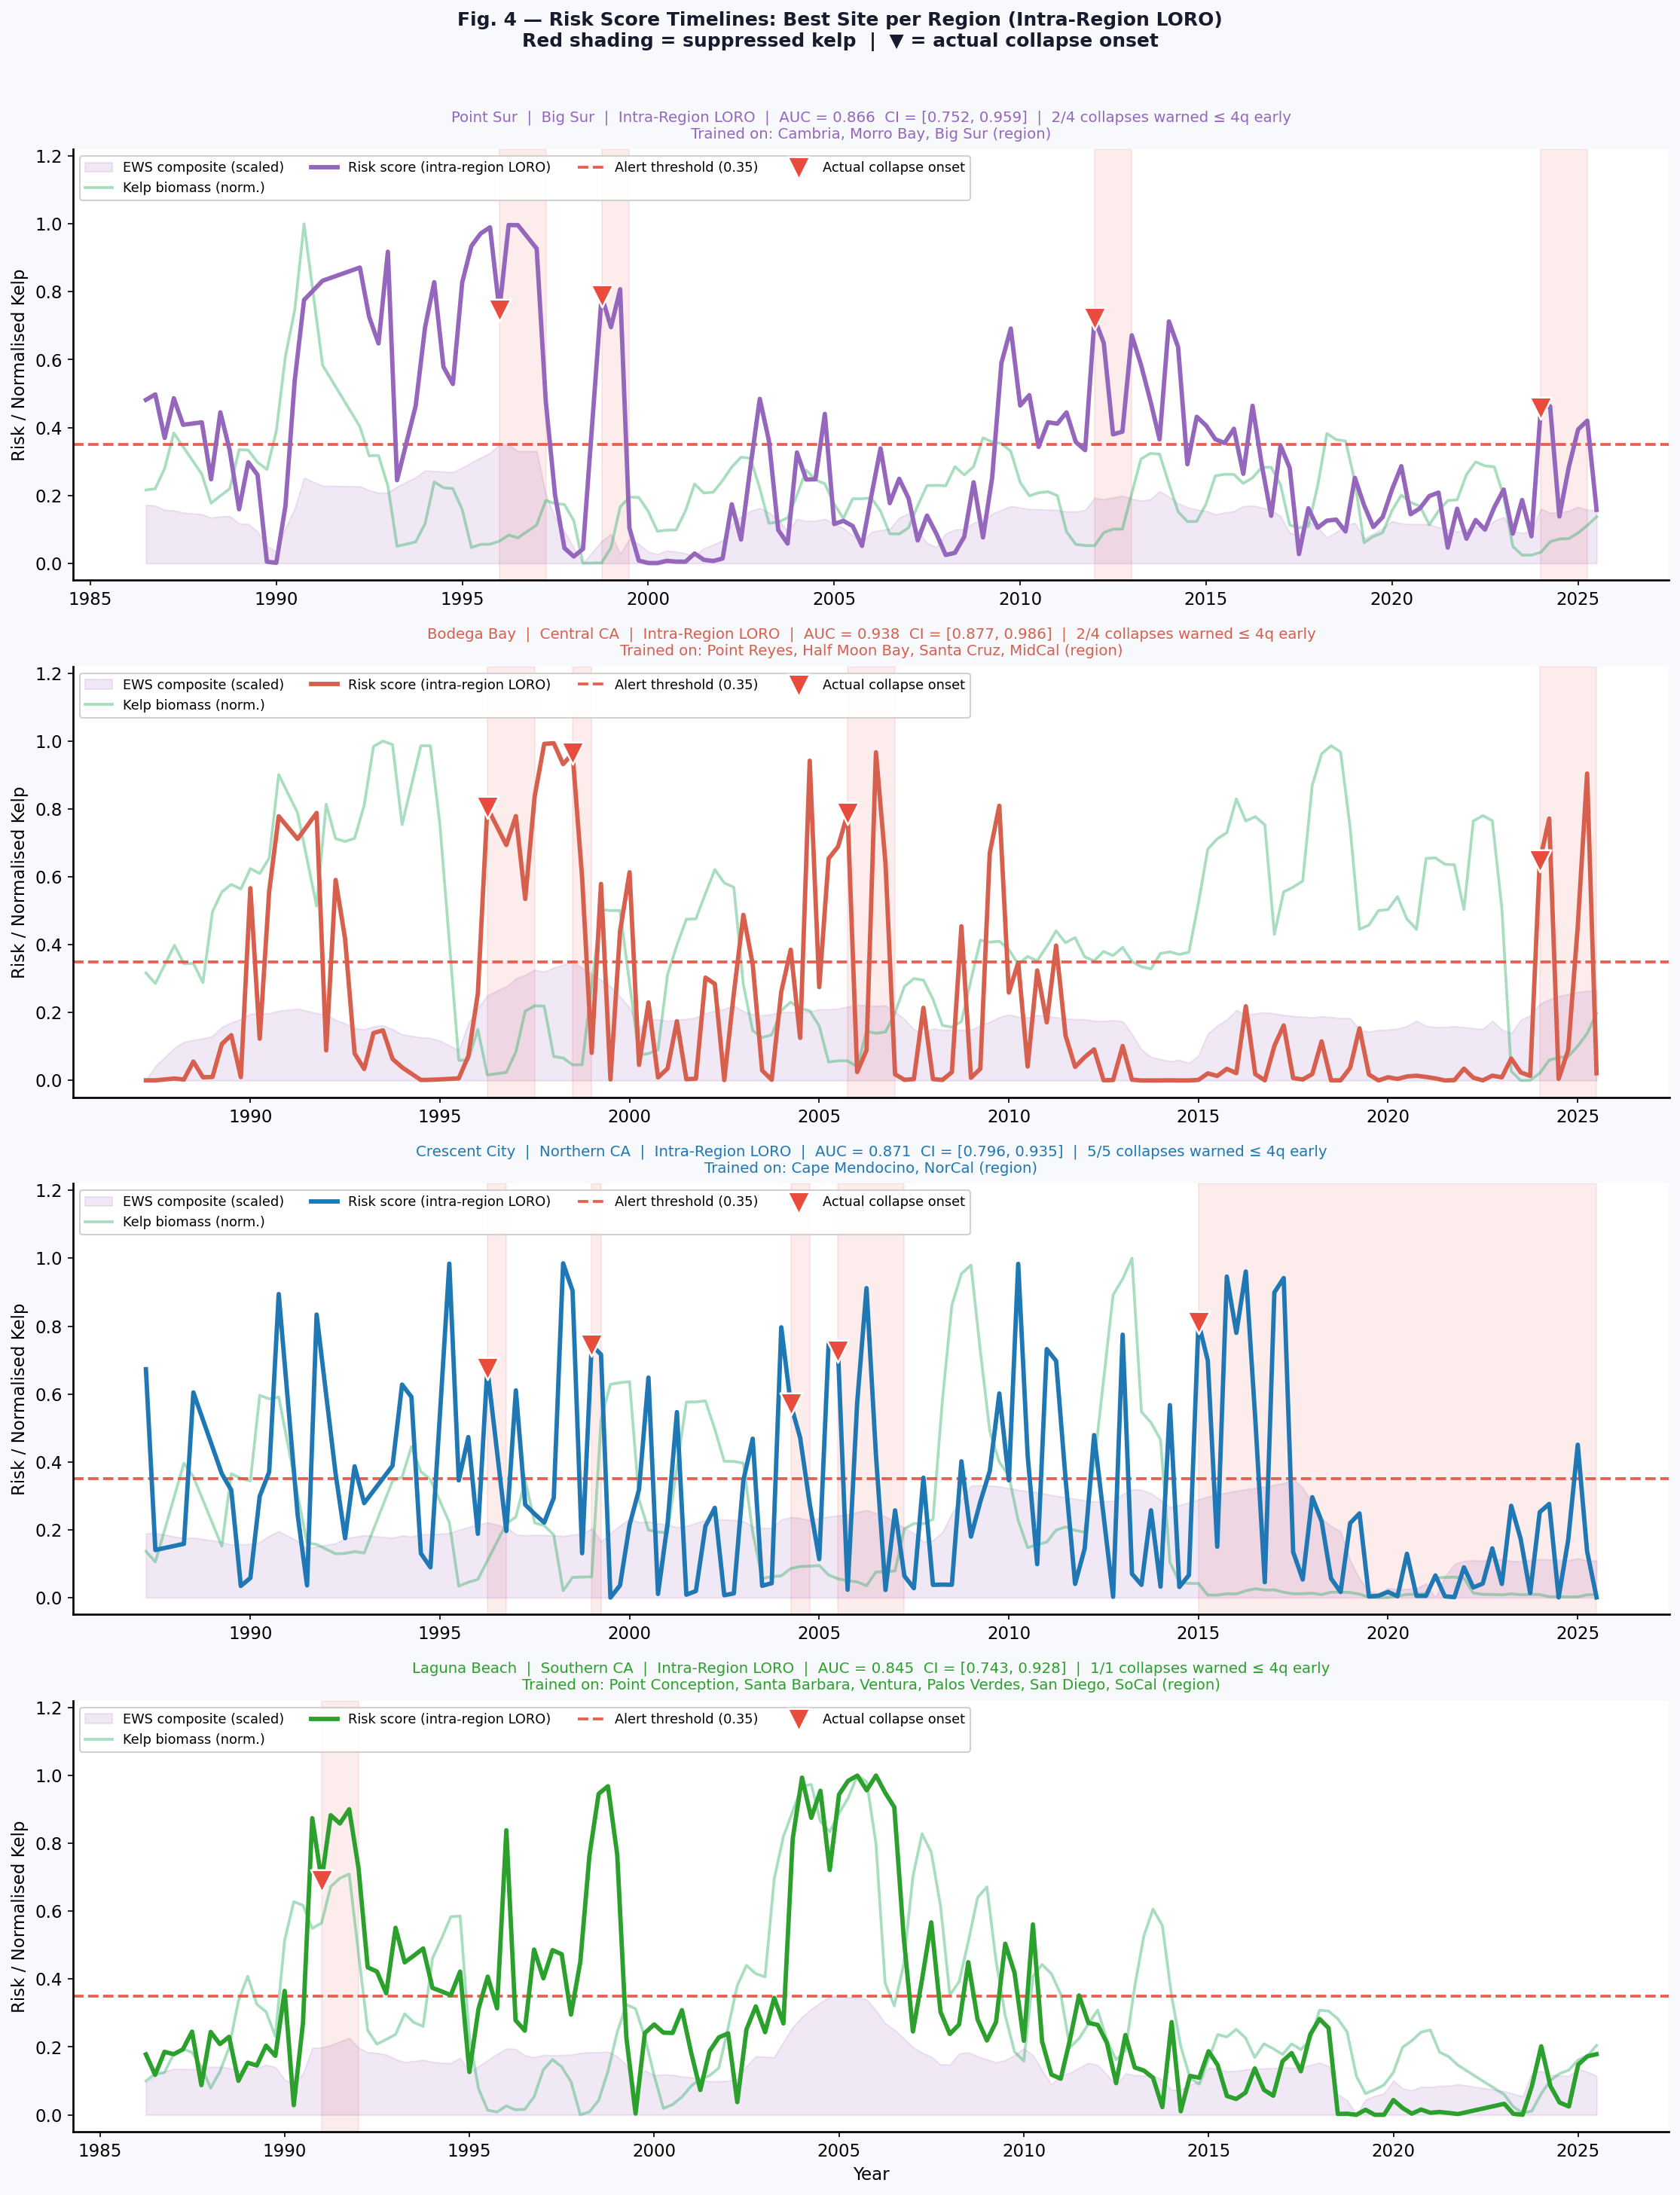

Saved fig4_risk_timelines.png


In [8]:
# ============================================================
# FIG 4 — RISK SCORE TIMELINES
# Best site from each region under intra-region LORO
# ============================================================
best_per_region = (
    valid.sort_values('auc', ascending=False)
         .groupby('region').first()
         .reset_index()
)

n_panels = len(best_per_region)
fig, axes = plt.subplots(n_panels, 1,
                         figsize=(15, 4.8*n_panels),
                         sharex=False)
if n_panels == 1: axes = [axes]
fig.patch.set_facecolor('#f7f9fc')

for ax, (_, brow) in zip(axes, best_per_region.iterrows()):
    sid    = brow['site_id']
    region = brow['region']
    col    = RCOL[region]

    if brow['prob'] is None or brow['t_idx'] is None:
        ax.text(0.5, 0.5, f'{brow["name"]} — no risk data',
                ha='center', transform=ax.transAxes)
        continue

    df_s  = site_data[sid]
    t_idx = brow['t_idx']
    risk  = pd.Series(brow['prob'],  index=t_idx)
    y_s   = pd.Series(brow['y'],     index=t_idx)
    supp  = df_s['suppressed'].reindex(t_idx).fillna(0).astype(int)
    onset = df_s['onset'].reindex(t_idx).fillna(0).astype(int)
    kc    = 'kelp_smooth' if 'kelp_smooth' in df_s else 'kelp_area'
    kelp  = df_s[kc].reindex(t_idx)
    kn    = (kelp-kelp.min())/(kelp.max()-kelp.min()+1e-9)
    ews   = df_s['ews_composite'].reindex(t_idx)
    ewsn  = (ews-ews.min())/(ews.max()-ews.min()+1e-9)

    ax.set_facecolor('#ffffff')

    # Suppression shading
    in_supp = False
    for t_pt, sv in supp.items():
        if sv==1 and not in_supp: t0=t_pt; in_supp=True
        elif sv==0 and in_supp:
            ax.axvspan(t0, t_pt, alpha=0.10, color='#e74c3c', zorder=0)
            in_supp=False
    if in_supp:
        ax.axvspan(t0, supp.index[-1], alpha=0.10,
                   color='#e74c3c', zorder=0)

    # EWS shading
    ax.fill_between(ewsn.index, 0, ewsn*0.35,
                    alpha=0.12, color='#8e44ad', zorder=1,
                    label='EWS composite (scaled)')

    ax.plot(kn.index, kn,   color='#27ae60', alpha=0.4,
            lw=1.8, label='Kelp biomass (norm.)')
    ax.plot(risk.index, risk, color=col, lw=2.8,
            label='Risk score (intra-region LORO)', zorder=3)
    ax.axhline(THRESHOLD, ls='--', color='#e74c3c', lw=1.8,
               alpha=0.9, label=f'Alert threshold ({THRESHOLD})')

    # Onset triangles
    onset_pts = risk[onset==1]
    ax.scatter(onset_pts.index, onset_pts.values,
               marker='v', s=200, color='#e74c3c', zorder=6,
               edgecolors='white', lw=1.2,
               label='Actual collapse onset')

    # Count warnings within WARN_WINDOW quarters of onset
    onset_locs = np.where(onset.values==1)[0]
    warned = sum(
        1 for k in onset_locs
        if (risk.values[max(0,k-WARN_WINDOW):k] >= THRESHOLD).any()
    )

    # What was the training pool?
    train_names = [SITES_DF[SITES_DF['site_id']==s]['name'].values[0]
                   for s in region_sites[region] if s != sid
                   and s in site_data]

    ax.set_title(
        f'{brow["name"]}  |  {RNAME[region]}  |  '
        f'Intra-Region LORO  |  '
        f'AUC = {brow["auc"]:.3f}  '
        f'CI = [{brow["ci_lo"]:.3f}, {brow["ci_hi"]:.3f}]  |  '
        f'{warned}/{int(onset.sum())} collapses warned ≤ {WARN_WINDOW}q early\n'
        f'Trained on: {", ".join(train_names)}',
        fontsize=9.5, color=col, pad=7
    )
    ax.set_ylabel('Risk / Normalised Kelp')
    ax.set_ylim(-0.05, 1.22)
    ax.legend(fontsize=8.5, ncol=4, loc='upper left', framealpha=0.9)

axes[-1].set_xlabel('Year')
fig.suptitle(
    'Fig. 4 — Risk Score Timelines: Best Site per Region (Intra-Region LORO)\n'
    'Red shading = suppressed kelp  |  ▼ = actual collapse onset',
    fontsize=12, fontweight='bold', y=1.01, color='#1a1a2e'
)
fig.tight_layout()
fig.savefig(FIG_DIR/'fig4_risk_timelines.png',
            dpi=200, bbox_inches='tight', facecolor='#f7f9fc')
plt.show()
print('Saved fig4_risk_timelines.png')

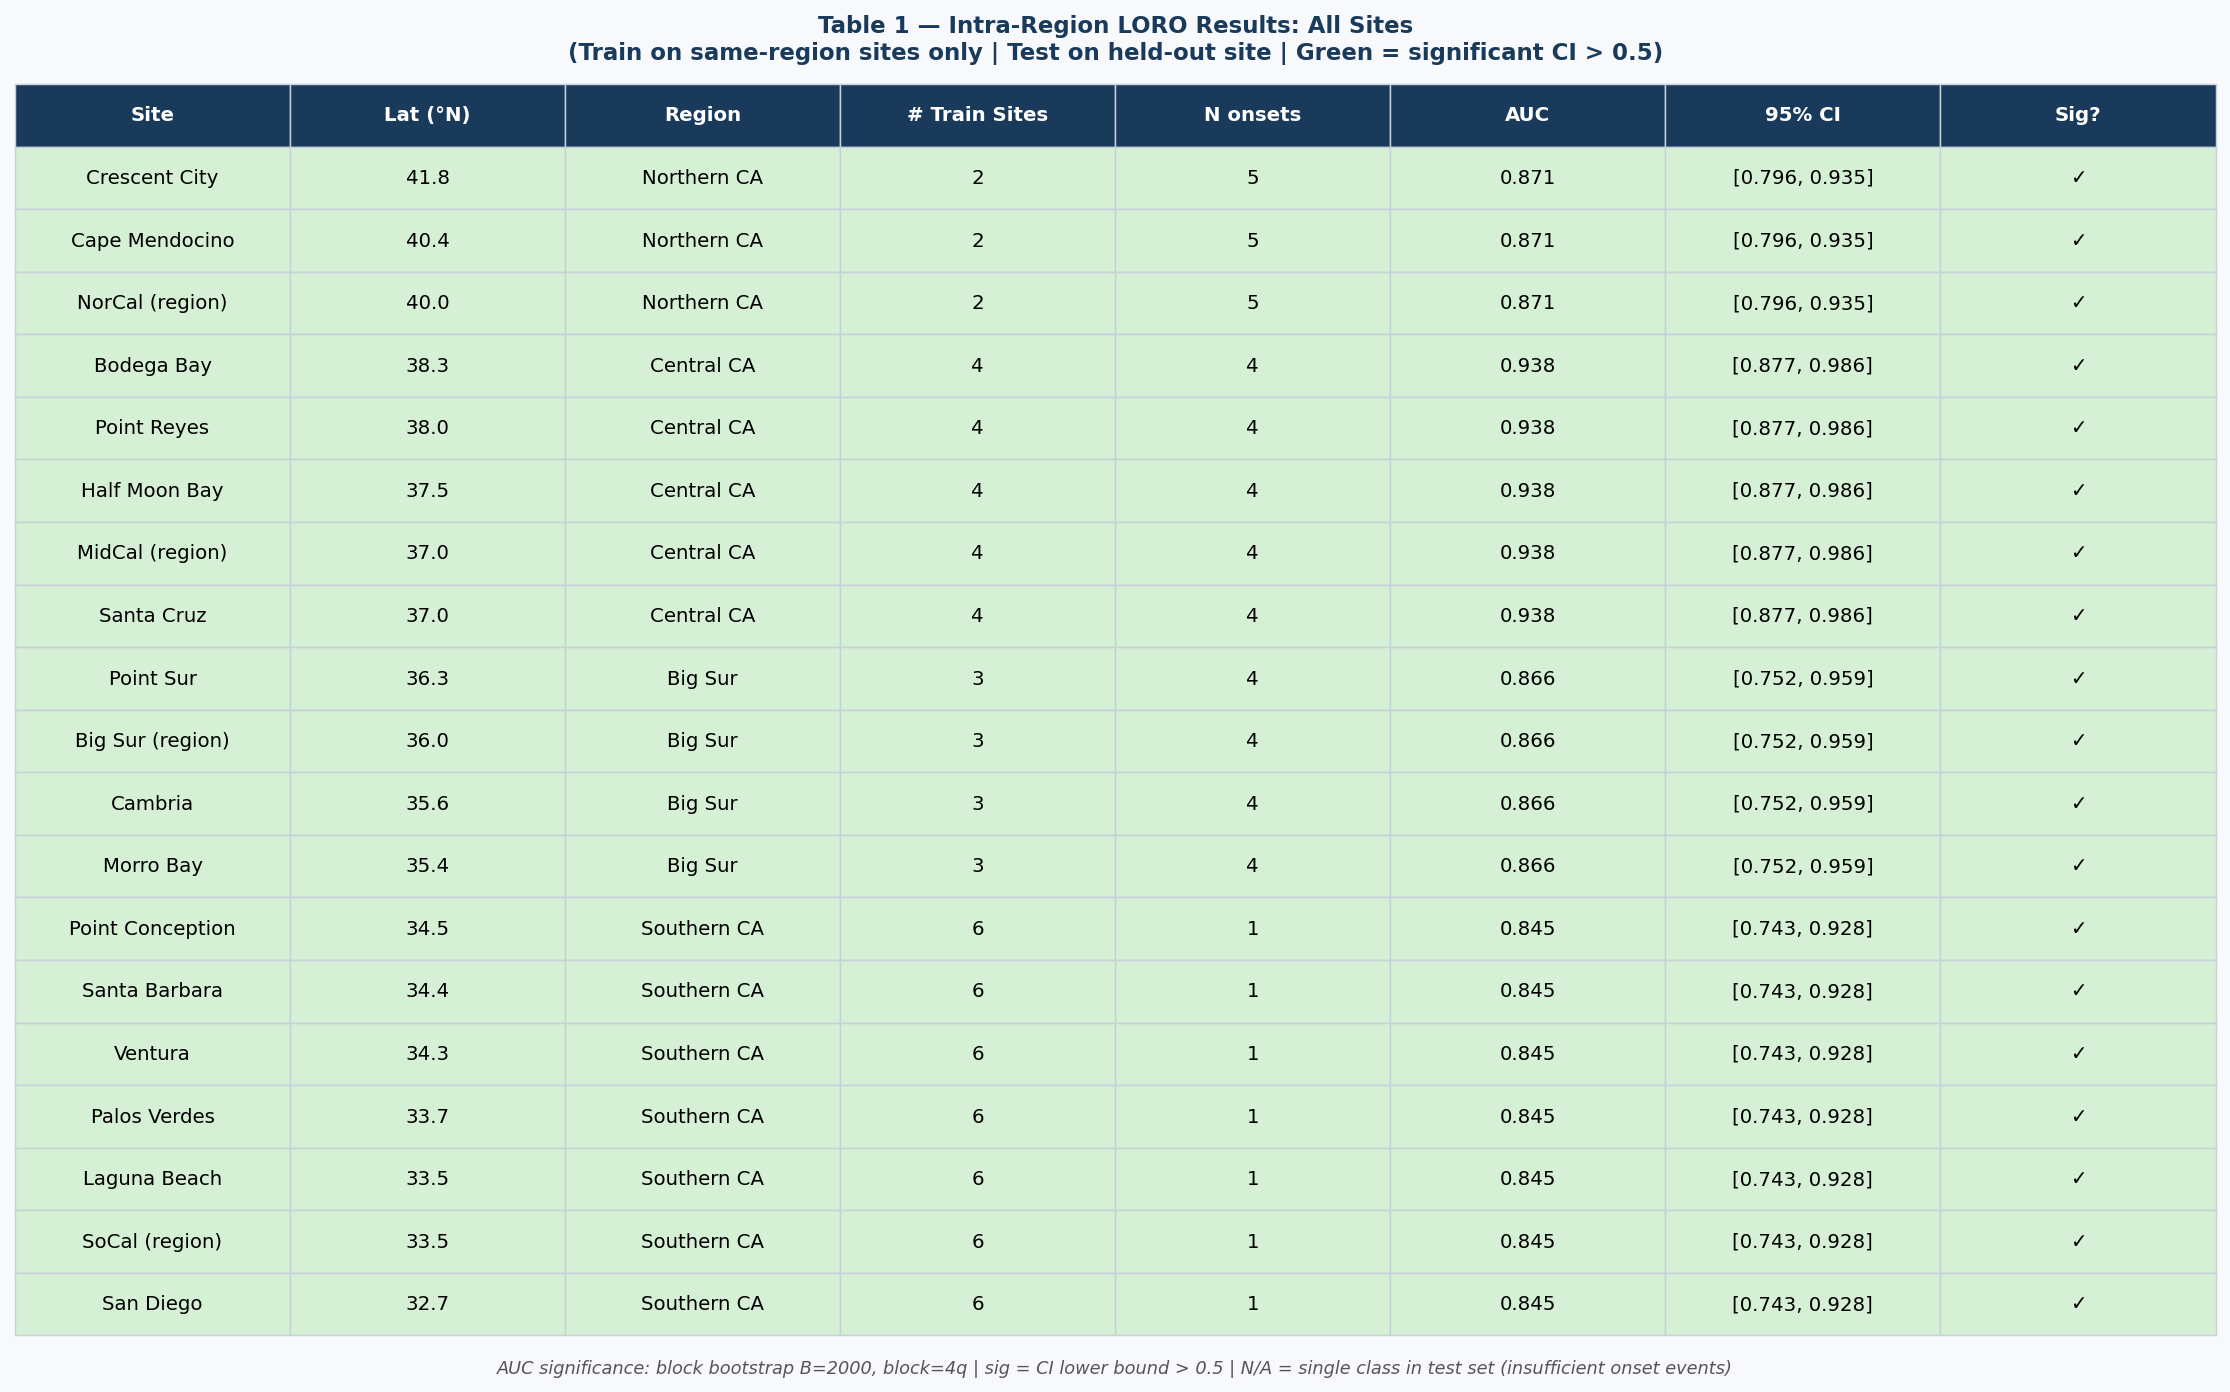

Saved fig5_summary_table.png


In [9]:
# ============================================================
# FIG 5 — SUMMARY TABLE
# Publication-quality table of all LORO results
# ============================================================
def styled_table(ax, df_tbl, title,
                 header_color='#1a3a5c',
                 alt_color='#f0f4f8',
                 sig_color='#d5f0d5',
                 fontsize=9.5):
    ax.axis('off')
    tbl = ax.table(
        cellText=df_tbl.values.tolist(),
        colLabels=df_tbl.columns.tolist(),
        cellLoc='center', loc='center', bbox=[0,0,1,1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    for (row, col_i), cell in tbl.get_celld().items():
        cell.set_edgecolor('#c8d0da')
        cell.set_linewidth(0.7)
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(color='white', fontweight='bold')
        else:
            dr = row - 1
            data_row = df_tbl.iloc[dr]
            if data_row.get('Sig?','') == '✓':
                cell.set_facecolor(sig_color)
            elif dr % 2 == 0:
                cell.set_facecolor(alt_color)
            else:
                cell.set_facecolor('#ffffff')
    if title:
        ax.set_title(title, fontsize=11, fontweight='bold',
                     pad=12, color='#1a3a5c')
    return tbl

# Build table data
tbl_rows = []
for _, r in res_df.sort_values('lat', ascending=False).iterrows():
    auc_s  = f"{r['auc']:.3f}"    if not pd.isna(r['auc'])   else 'N/A'
    ci_s   = (f"[{r['ci_lo']:.3f}, {r['ci_hi']:.3f}]"
              if not pd.isna(r['ci_lo']) else 'N/A')
    tbl_rows.append({
        'Site':            r['name'],
        'Lat (°N)':        f"{r['lat']:.1f}",
        'Region':          RNAME.get(r['region'], r['region']),
        '# Train Sites':   str(int(r['n_train_sites'])) if not pd.isna(r.get('n_train_sites',np.nan)) else 'N/A',
        'N onsets':        str(int(r['n_onset'])),
        'AUC':             auc_s,
        '95% CI':          ci_s,
        'Sig?':            '✓' if r['sig'] else '—',
    })
tbl_df = pd.DataFrame(tbl_rows)

fig, ax = plt.subplots(figsize=(15, max(4, 1.4 + len(tbl_df)*0.42)))
fig.patch.set_facecolor('#f7f9fc')
styled_table(
    ax, tbl_df,
    title='Table 1 — Intra-Region LORO Results: All Sites\n'
          '(Train on same-region sites only | Test on held-out site | '
          'Green = significant CI > 0.5)',
    header_color='#1a3a5c'
)
ax.text(0.5, -0.03,
    'AUC significance: block bootstrap B=2000, block=4q | '
    'sig = CI lower bound > 0.5 | '
    'N/A = single class in test set (insufficient onset events)',
    transform=ax.transAxes, ha='center', fontsize=8.5,
    color='#555', style='italic')

fig.tight_layout()
fig.savefig(FIG_DIR/'fig5_summary_table.png',
            dpi=200, bbox_inches='tight', facecolor='#f7f9fc')
plt.show()
print('Saved fig5_summary_table.png')

In [10]:
# ============================================================
# FINAL STATS PRINTOUT  (copy-paste ready for slides)
# ============================================================
c_v  = valid[valid['central']]['auc'].dropna()
nc_v = valid[~valid['central']]['auc'].dropna()
if len(c_v) > 1 and len(nc_v) > 1:
    _, p_geo = mannwhitneyu(c_v, nc_v, alternative='greater')
    geo_str  = f'{p_geo:.4f}'
else:
    geo_str = 'N/A'

print('='*65)
print('  INTRA-REGION LORO — SLIDE/PAPER STATS')
print('='*65)
print(f"""
HEADLINE:
  Valid folds:         {len(valid)}/{len(res_df)}
  Mean AUC:            {valid['auc'].mean():.3f}
  Significant sites:   {int(valid['sig'].sum())}/{len(valid)}
  Central CA mean AUC: {c_v.mean():.3f}  (n={len(c_v)})
  Non-central mean:    {nc_v.mean():.3f}  (n={len(nc_v)})
  Central > Non-cent p:{geo_str}

WHAT THIS SHOWS:
  Standard LORO trains across different oceanographic regimes,
  so some AUC could come from regime-level differences, not
  from EWS dynamics.

  This intra-region design uses ONLY within-regime training data.
  If AUC remains above 0.5, the EWS signal is genuinely learnable
  from within-regime dynamics alone — a stronger mechanistic claim.

PER REGION:""")
for r in ['norcal','midcal','bigsur','socal']:
    sub = valid[valid['region']==r]
    if len(sub)==0: continue
    print(f'  {RNAME[r]:15s}: mean={sub["auc"].mean():.3f}  '
          f'sig={int(sub["sig"].sum())}/{len(sub)}')

print(f"""
ALL FIGURES SAVED TO: {FIG_DIR.resolve()}
  fig1_forest_plot.png
  fig2_method_comparison.png
  fig3_roc_curves.png
  fig4_risk_timelines.png
  fig5_summary_table.png
""")

  INTRA-REGION LORO — SLIDE/PAPER STATS

HEADLINE:
  Valid folds:         19/19
  Mean AUC:            0.878
  Significant sites:   19/19
  Central CA mean AUC: 0.938  (n=5)
  Non-central mean:    0.856  (n=14)
  Central > Non-cent p:0.0004

WHAT THIS SHOWS:
  Standard LORO trains across different oceanographic regimes,
  so some AUC could come from regime-level differences, not
  from EWS dynamics.

  This intra-region design uses ONLY within-regime training data.
  If AUC remains above 0.5, the EWS signal is genuinely learnable
  from within-regime dynamics alone — a stronger mechanistic claim.

PER REGION:
  Northern CA    : mean=0.871  sig=3/3
  Central CA     : mean=0.938  sig=5/5
  Big Sur        : mean=0.866  sig=4/4
  Southern CA    : mean=0.845  sig=7/7

ALL FIGURES SAVED TO: /Users/tonylin/Documents/kelp_project/5_FIGURES/loro_intraregion
  fig1_forest_plot.png
  fig2_method_comparison.png
  fig3_roc_curves.png
  fig4_risk_timelines.png
  fig5_summary_table.png

